In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

adata = sc.read_h5ad("dataset_co_mo.h5ad")

In [2]:
# Extract source and receiver genes efficiently
gl_source = ['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'] # All values from the first column
#gl_source = ['TGFBR2', 'PDGFB'] # All values from the first column

#gl_recv =['TGFB1', 'IL6', 'PDGFRB']  # All values from the second column
gl_recv =['TGFB1', 'PDGFRB']  # All values from the second column

ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 
adata_ct1 = adata[ict1, gl_source]
adata_ct2 = adata[ict2, gl_recv]
print(adata_ct1)
print(adata_ct2)

Xct1 = adata_ct1.X.copy()
Xct2 = adata_ct2.X.copy()
Xct1 = Xct1.toarray()
Xct2 = Xct2.toarray()
# Compute cell percentace of cell type 1 count matrix
Xct1p = np.sum(Xct1>0, axis=0)/len(Xct1[:,0])
Xct2p = np.sum(Xct2>0, axis=0)/len(Xct2[:,0])

print("CT1 Percentages:", Xct1p)
print("CT2 Percentages:", Xct2p)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
ct1_percentages = Xct1p * np.pi*2
ct2_percentages = Xct2p * np.pi*2
#ct1_percentages = (Xct1p-0.5) * np.pi*2*0.9
#ct2_percentages = (Xct2p-0.5) * np.pi*2*0.9
#ct1_percentages = (Xct1p-0.5) * np.pi # This works to keep the state within +x, +y, or +x, -y, 
#ct2_percentages = (Xct2p-0.5) * np.pi
# Display the resulting scaled data
print("Scaled ct1_data:\n", ct1_percentages)
print("Scaled ct2_data:\n", ct2_percentages)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
View of AnnData object with n_obs × n_vars = 2788 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
CT1 Percentages: [0.36759729 0.8071066  0.89932318 0.09898477]
CT2 Percentages: [0.42969871 0.29196557]
Scaled ct1_data:
 [2.30968191 5.07120032 5.6506142  0.62193966]
Scaled ct2_data:
 [2.69987661 1.83447376]


In [3]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram

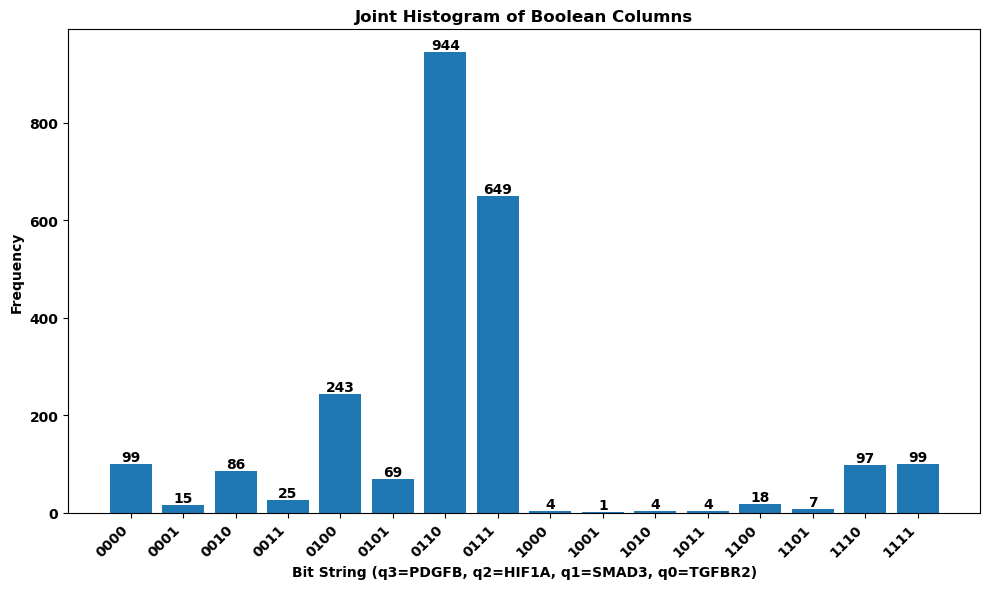

Joint Counts: Counter({'0110': 944, '1110': 649, '0010': 243, '0000': 99, '1111': 99, '0111': 97, '0100': 86, '1010': 69, '1100': 25, '0011': 18, '1000': 15, '1011': 7, '0101': 4, '1101': 4, '0001': 4, '1001': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [4]:
# Example Usage (assuming Xct1 is defined):
Xct1bool = Xct1 > 0  # Create boolean array

joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1bool)

num_qubits = Xct1bool.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits, reverse_bits=True, features=gl_source )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

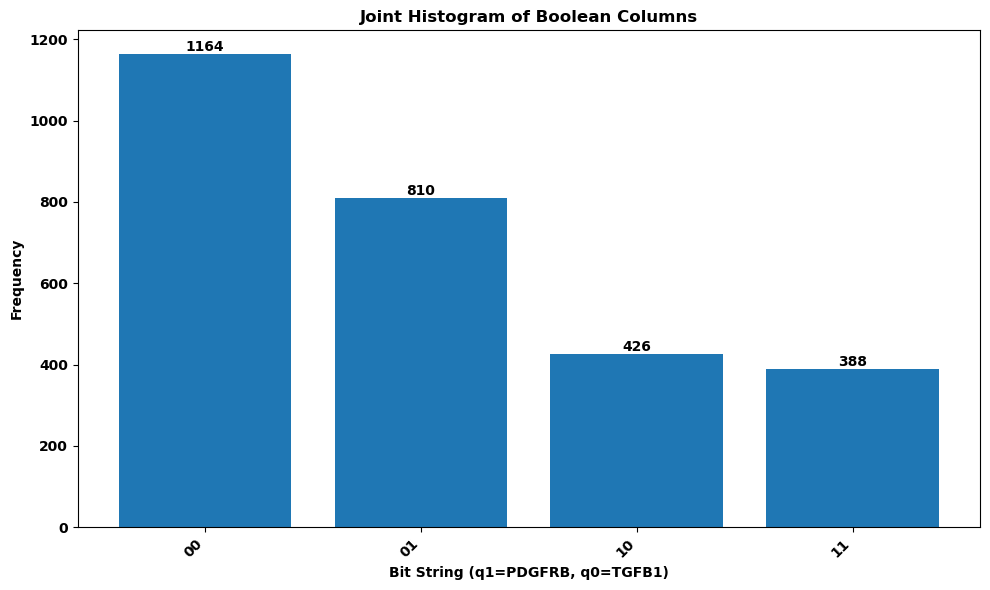

Joint Counts: Counter({'00': 1164, '10': 810, '01': 426, '11': 388})
Bit Strings: ['00', '01', '10', '11']


In [5]:
# Example Usage (assuming Xct1 is defined):
Xct2bool = Xct2 > 0  # Create boolean array

joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2bool)

num_qubits2 = Xct2bool.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [6]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


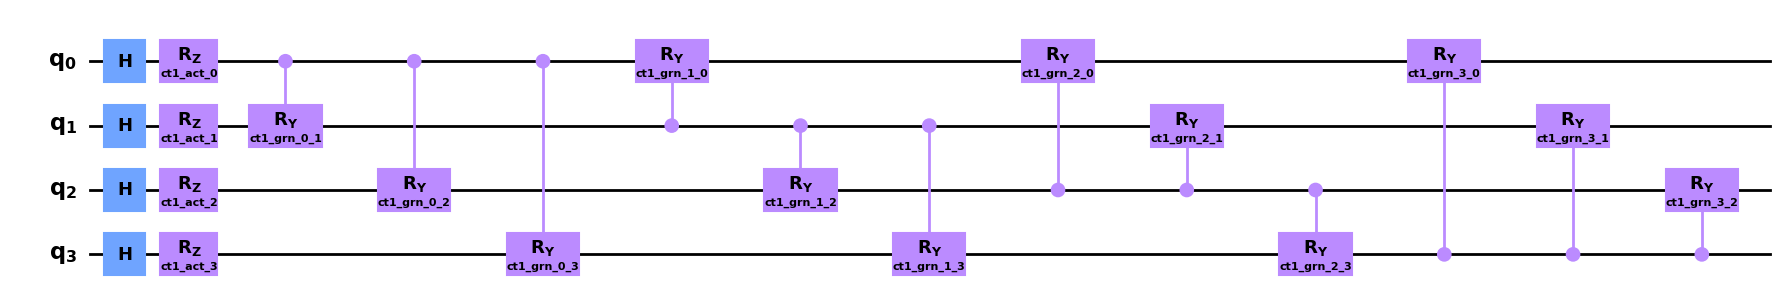

In [7]:
ng_ct1 = len(gl_source)  # Assuming gl_source is defined elsewhere
ansatz_grn_ct1_mo = create_grn_ansatz(ng_ct1, "CT1")
ansatz_grn_ct1_mo.draw(output="mpl", style="clifford", fold=40)

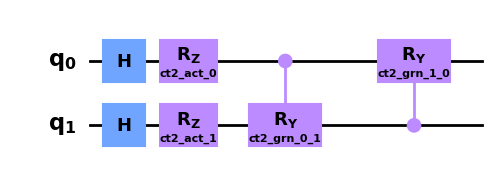

In [8]:
ng_ct2 = len(gl_recv)  #Example for a second cell type
ansatz_grn_ct2_mo = create_grn_ansatz(ng_ct2, "CT2")
ansatz_grn_ct2_mo.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['IZZI', 'IIZI', 'ZZZZ', 'ZZZI', 'IZZZ', 'IZII', 'ZIZI', 'ZZII', 'IIZZ', 'ZIII', 'IZIZ', 'ZZIZ', 'IIIZ', 'ZIIZ', 'ZIZZ'],
              coeffs=[-944.+0.j, -243.+0.j,  -99.+0.j, -649.+0.j,  -97.+0.j,  -86.+0.j,
  -69.+0.j,  -25.+0.j,  -18.+0.j,  -15.+0.j,   -4.+0.j,   -4.+0.j,
   -4.+0.j,   -1.+0.j,   -7.+0.j])
Static Parameters: {Parameter(ct1_act_0): 2.3096819086036633, Parameter(ct1_act_1): 5.071200324068803, Parameter(ct1_act_2): 5.650614197573519, Parameter(ct1_act_3): 0.6219396623857967}
Variable Parameters: [Parameter(ct1_grn_0_1), Parameter(ct1_grn_0_2), Parameter(ct1_grn_0_3), Parameter(ct1_grn_1_0), Parameter(ct1_grn_1_2), Parameter(ct1_grn_1_3), Parameter(ct1_grn_2_0), Parameter(ct1_grn_2_1), Parameter(ct1_grn_2_3), Parameter(ct1_grn_3_0), Parameter(ct1_grn_3_1), Parameter(ct1_grn_3_2)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -1148.4846605689343
        x: 

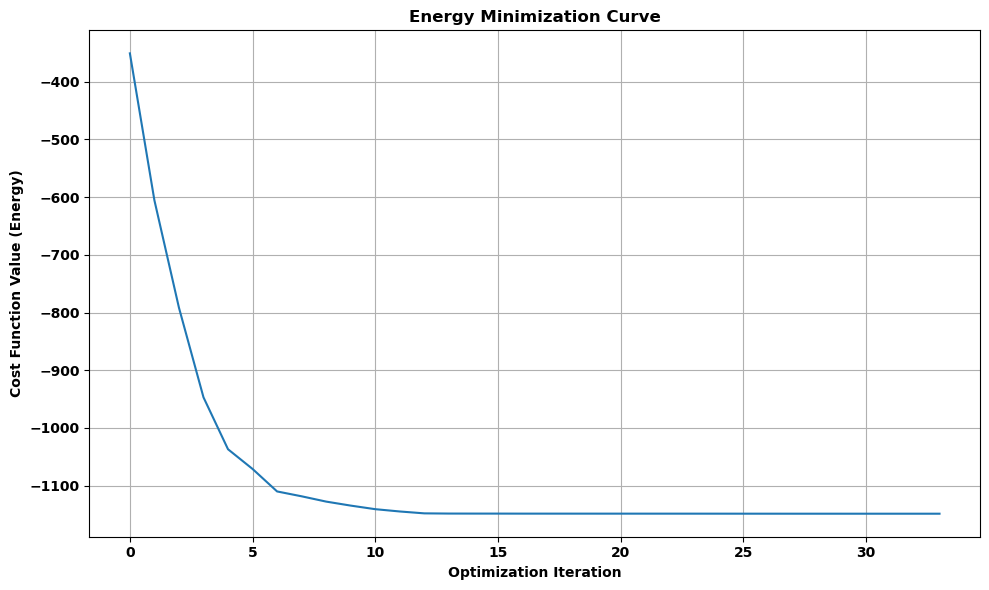

In [9]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features = Xct1bool.shape[1]  # Get the number of features dynamically

interaction_observable_ct1_mo = create_interaction_observable_from_histogram(joint_counts_ct1_mo, num_features, min_ones = 1, standardize=False)
print("Interaction observable CT1 from histogram:", interaction_observable_ct1_mo)

static_params, variable_params = create_parameter_dictionaries(ansatz_grn_ct1_mo, ct1_percentages)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct1_mo = static_params.copy()  # Start with static parameters
all_params_ct1_mo.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct1_mo, ansatz_grn_ct1_mo, interaction_observable_ct1_mo, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct1_mo, ansatz_grn_ct1_mo, interaction_observable_ct1_mo, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params_ct1_mo[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'0010': 35, '1000': 302, '0001': 510, '0110': 674, '0111': 398, '0000': 162, '1110': 91, '1111': 96, '1001': 78, '0011': 2, '1100': 2, '1011': 2, '1101': 2, '0101': 4, '0100': 5, '1010': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


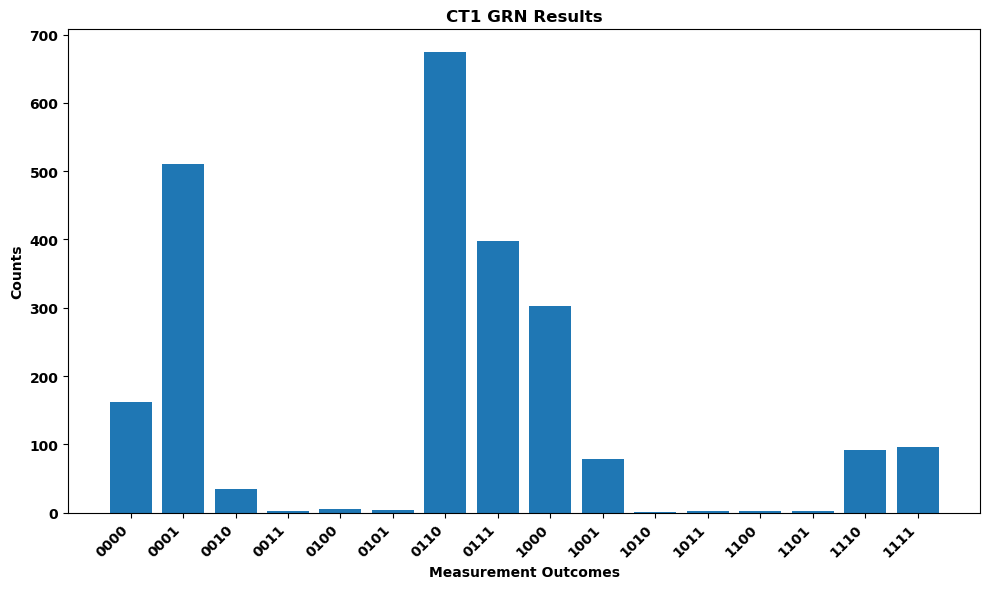

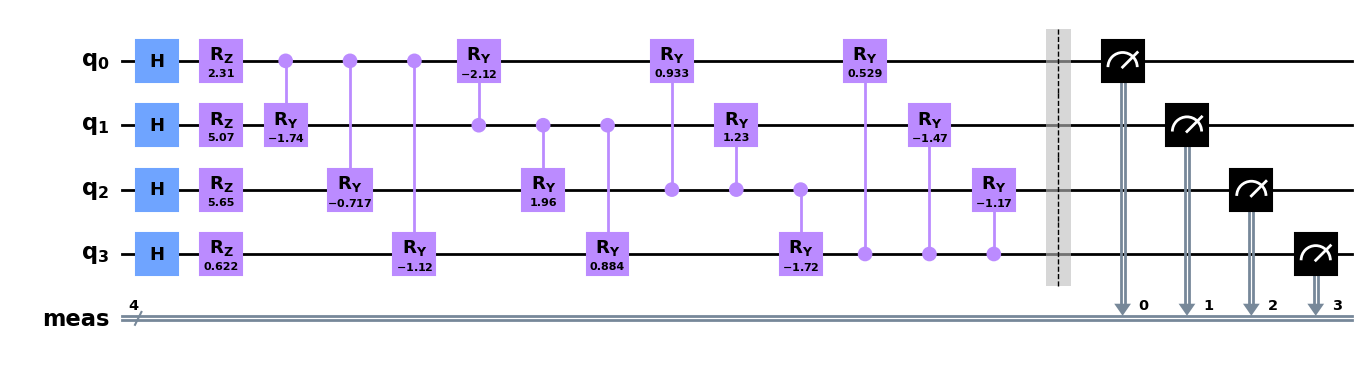

In [10]:
counts_ct1_mo, bound_circuit_ct1_mo = evaluate_and_plot_ansatz(ansatz_grn_ct1_mo, all_params_ct1_mo, shots=sum(joint_counts_ct1_mo.values()), title="CT1 GRN Results")

bound_circuit_ct1_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT2 from histogram: SparsePauliOp(['ZZ', 'ZI', 'IZ'],
              coeffs=[-388.+0.j, -810.+0.j, -426.+0.j])
Static Parameters: {Parameter(ct2_act_0): 2.6998766133433083, Parameter(ct2_act_1): 1.8344737589828493}
Variable Parameters: [Parameter(ct2_grn_0_1), Parameter(ct2_grn_1_0)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -57.498994105399824
        x: [ 1.397e+00  1.135e+00]
      nit: 8
      jac: [ 1.080e-04  2.132e-05]
     nfev: 33
     njev: 11
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


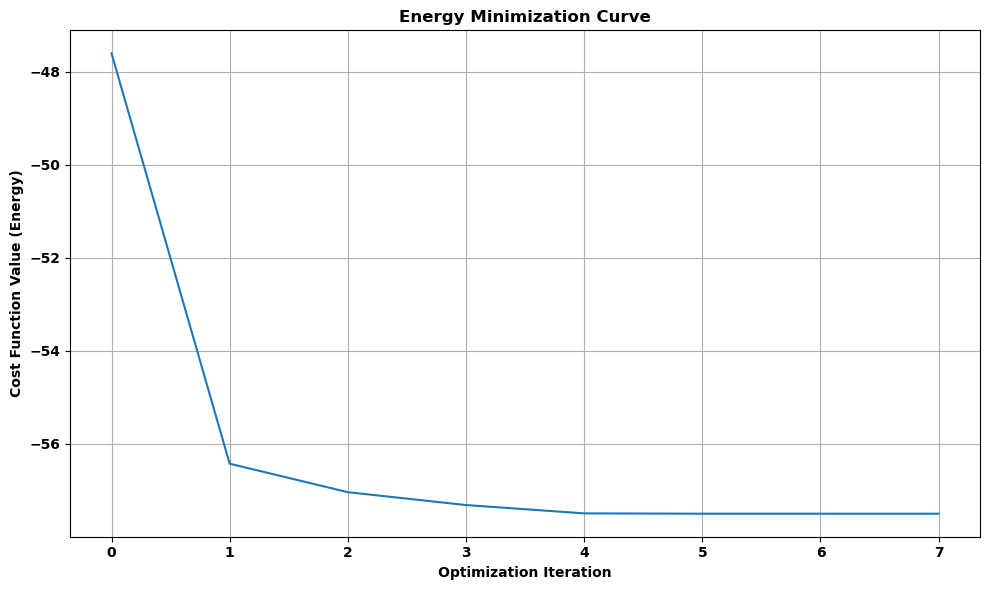

In [11]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features2 = Xct2bool.shape[1]  # Get the number of features dynamically

interaction_observable_ct2_mo = create_interaction_observable_from_histogram(joint_counts_ct2_mo, num_features2, min_ones = 1, standardize=False)
print("Interaction observable CT2 from histogram:", interaction_observable_ct2_mo)

static_params2, variable_params2 = create_parameter_dictionaries(ansatz_grn_ct2_mo, ct2_percentages)

print("Static Parameters:", static_params2)
print("Variable Parameters:", variable_params2)

estimator = StatevectorEstimator()
# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params2))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct2_mo = static_params2.copy()  # Start with static parameters
all_params_ct2_mo.update(dict(zip(variable_params2, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args, using a lambda for the callback
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct2_mo, ansatz_grn_ct2_mo, interaction_observable_ct2_mo, estimator, variable_params2),
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct2_mo, ansatz_grn_ct2_mo, interaction_observable_ct2_mo, estimator, variable_params2))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params2, optimized_variable_parameters):
    all_params_ct2_mo[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'01': 891, '10': 804, '00': 725, '11': 368}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


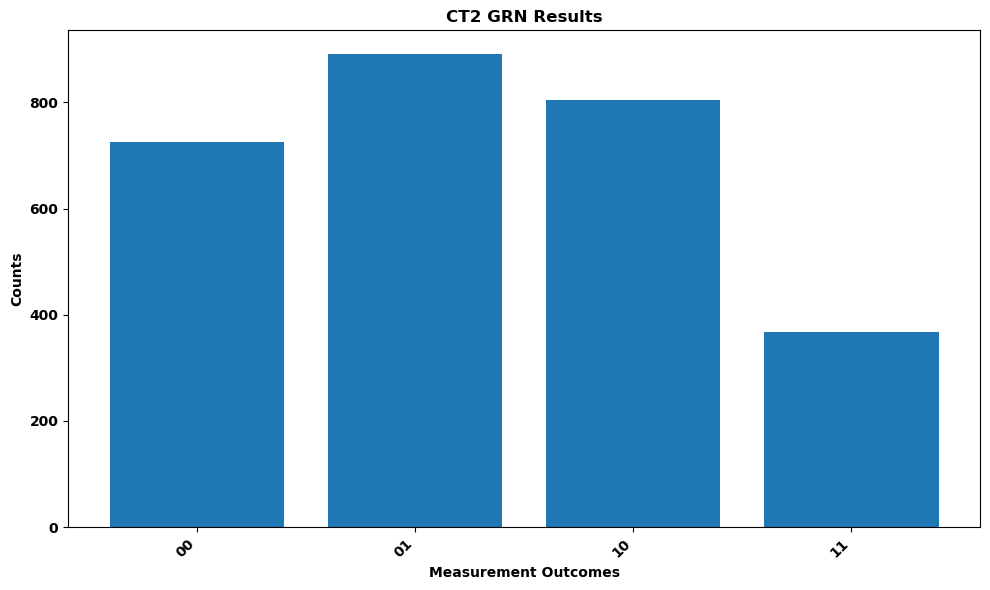

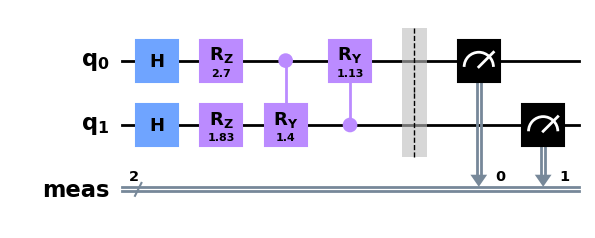

In [12]:
counts_ct2_mo, bound_circuit_ct2_mo = evaluate_and_plot_ansatz(ansatz_grn_ct2_mo, all_params_ct2_mo, shots=sum(joint_counts_ct2_mo.values()), title="CT2 GRN Results")

bound_circuit_ct2_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [13]:
# Extract source and receiver genes efficiently
#gl_source = ['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'] # All values from the first column
#gl_source = ['TGFBR2', 'PDGFB'] # All values from the first column

#gl_recv =['TGFB1', 'IL6', 'PDGFRB']  # All values from the second column
#gl_recv =['TGFB1', 'PDGFRB']  # All values from the second column

ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 
adata_ct1 = adata[ict1, gl_source]
adata_ct2 = adata[ict2, gl_recv]
print(adata_ct1)
print(adata_ct2)

Xct1 = adata_ct1.X.copy()
Xct2 = adata_ct2.X.copy()
Xct1 = Xct1.toarray()
Xct2 = Xct2.toarray()
# Compute cell percentace of cell type 1 count matrix
Xct1p = np.sum(Xct1>0, axis=0)/len(Xct1[:,0])
Xct2p = np.sum(Xct2>0, axis=0)/len(Xct2[:,0])

print("CT1 Percentages:", Xct1p)
print("CT2 Percentages:", Xct2p)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
ct1_percentages = Xct1p * np.pi*2
ct2_percentages = Xct2p * np.pi*2
#ct1_percentages = (Xct1p-0.5) * np.pi*2*0.9
#ct2_percentages = (Xct2p-0.5) * np.pi*2*0.9
#ct1_percentages = (Xct1p-0.5) * np.pi
#ct2_percentages = (Xct2p-0.5) * np.pi
# Display the resulting scaled data
print("Scaled ct1_data:\n", ct1_percentages)
print("Scaled ct2_data:\n", ct2_percentages)

View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
View of AnnData object with n_obs × n_vars = 1324 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
CT1 Percentages: [0.3748232  0.79915134 0.88260255 0.29915134]
CT2 Percentages: [0.51812689 0.41993958]
Scaled ct1_data:
 [2.3550836  5.02121598 5.54555535 1.87962333]
Scaled ct2_data:
 [3.25548725 2.63855818]


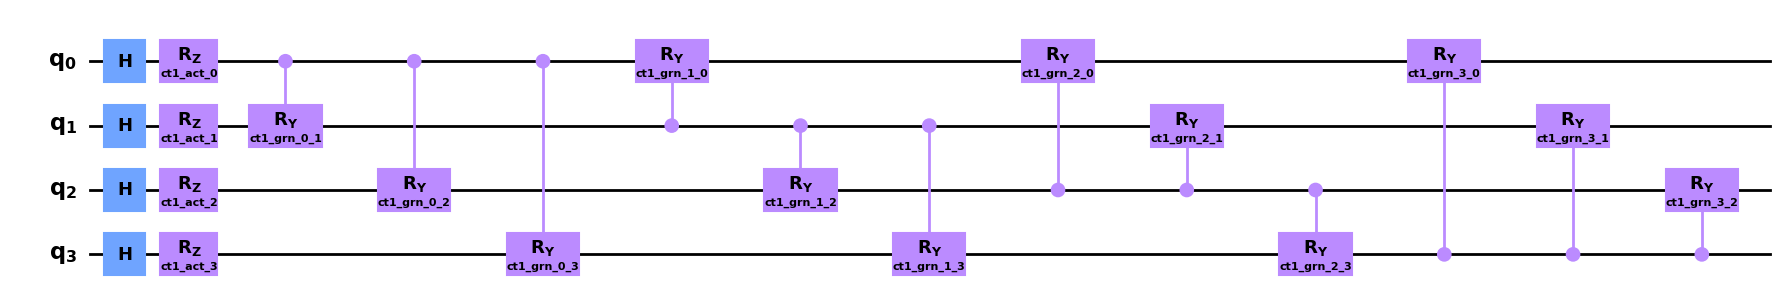

In [14]:
ng_ct1 = len(gl_source)  # Assuming gl_source is defined elsewhere
ansatz_grn_ct1_co = create_grn_ansatz(ng_ct1, "CT1")
ansatz_grn_ct1_co.draw(output="mpl", style="clifford", fold=40)

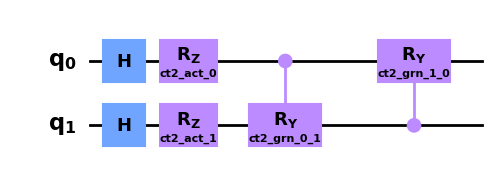

In [15]:
ng_ct2 = len(gl_recv)  #Example for a second cell type
ansatz_grn_ct2_co = create_grn_ansatz(ng_ct2, "CT2")
ansatz_grn_ct2_co.draw(output="mpl", style="clifford", fold=40)

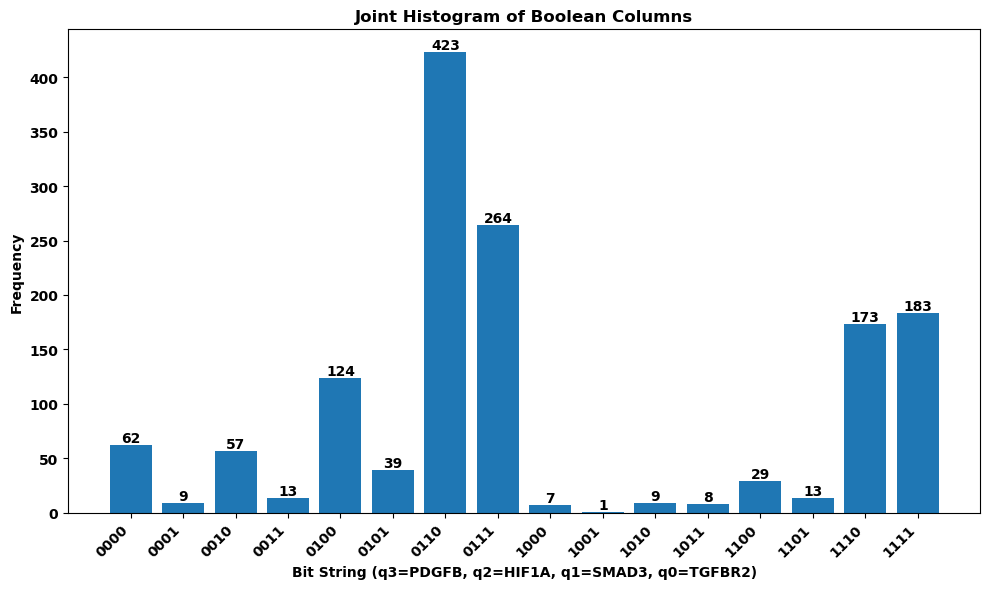

Joint Counts: Counter({'0110': 423, '1110': 264, '1111': 183, '0111': 173, '0010': 124, '0000': 62, '0100': 57, '1010': 39, '0011': 29, '1100': 13, '1011': 13, '1000': 9, '0101': 9, '1101': 8, '0001': 7, '1001': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [16]:
# Example Usage (assuming Xct1 is defined):
Xct1bool = Xct1 > 0  # Create boolean array

joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1bool)

num_qubits = Xct1bool.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_co, num_qubits, reverse_bits=True, features=gl_source)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

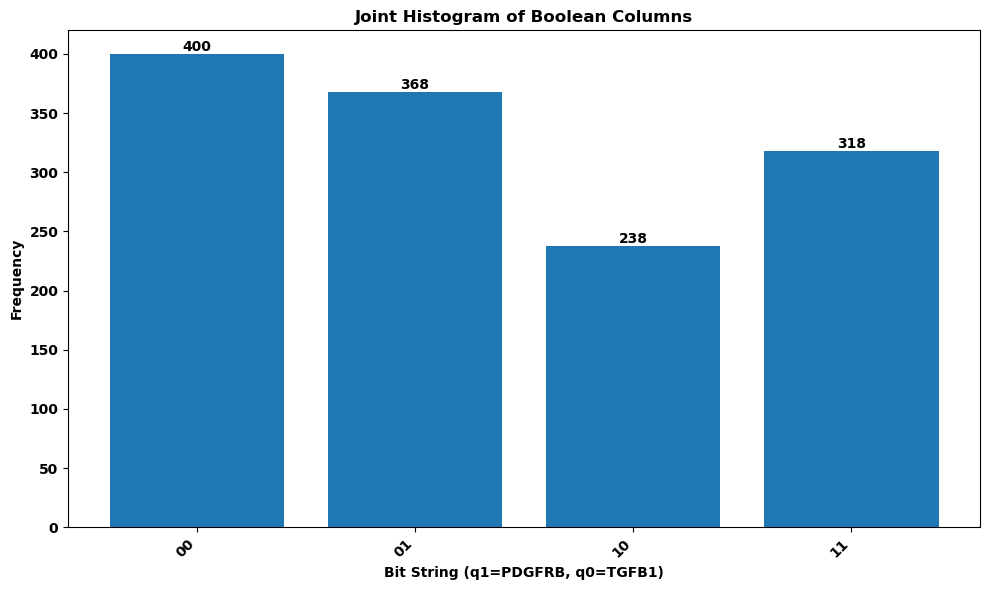

Joint Counts: Counter({'00': 400, '10': 368, '11': 318, '01': 238})
Bit Strings: ['00', '01', '10', '11']


In [17]:
# Example Usage (assuming Xct1 is defined):
Xct2bool = Xct2 > 0  # Create boolean array

joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2bool)

num_qubits2 = Xct2bool.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

Interaction observable CT1 from histogram: SparsePauliOp(['IZZZ', 'ZZZI', 'IIZZ', 'IZZI', 'IZII', 'IIZI', 'ZZIZ', 'ZZZZ', 'ZIII', 'ZIZI', 'ZZII', 'IIIZ', 'ZIZZ', 'IZIZ', 'ZIIZ'],
              coeffs=[-173.+0.j, -264.+0.j,  -29.+0.j, -423.+0.j,  -57.+0.j, -124.+0.j,
   -8.+0.j, -183.+0.j,   -9.+0.j,  -39.+0.j,  -13.+0.j,   -7.+0.j,
  -13.+0.j,   -9.+0.j,   -1.+0.j])
Static Parameters: {Parameter(ct1_act_0): 2.3550836017009766, Parameter(ct1_act_1): 5.0212159809851, Parameter(ct1_act_2): 5.545555348910979, Parameter(ct1_act_3): 1.8796233273953076}
Variable Parameters: [Parameter(ct1_grn_0_1), Parameter(ct1_grn_0_2), Parameter(ct1_grn_0_3), Parameter(ct1_grn_1_0), Parameter(ct1_grn_1_2), Parameter(ct1_grn_1_3), Parameter(ct1_grn_2_0), Parameter(ct1_grn_2_1), Parameter(ct1_grn_2_3), Parameter(ct1_grn_3_0), Parameter(ct1_grn_3_1), Parameter(ct1_grn_3_2)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -498.63843755094854
        x: [-

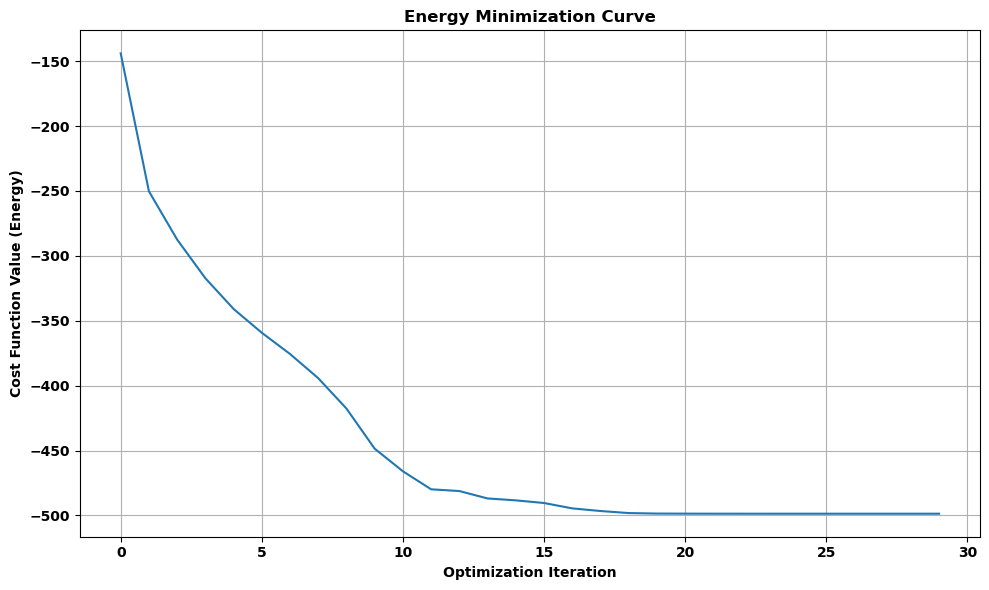

In [18]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features = Xct1bool.shape[1]  # Get the number of features dynamically

interaction_observable_ct1_co = create_interaction_observable_from_histogram(joint_counts_ct1_co, num_features, min_ones = 1, standardize=False)
print("Interaction observable CT1 from histogram:", interaction_observable_ct1_co)

static_params, variable_params = create_parameter_dictionaries(ansatz_grn_ct1_co, ct1_percentages)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct1_co = static_params.copy()  # Start with static parameters
all_params_ct1_co.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct1_co, ansatz_grn_ct1_co, interaction_observable_ct1_co, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct1_co, ansatz_grn_ct1_co, interaction_observable_ct1_co, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params_ct1_co[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'0110': 566, '1111': 12, '1000': 519, '0000': 93, '1011': 6, '1110': 56, '0001': 75, '1101': 38, '0010': 19, '1001': 7, '0101': 2, '0011': 14, '1010': 4, '0111': 1, '0100': 2}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


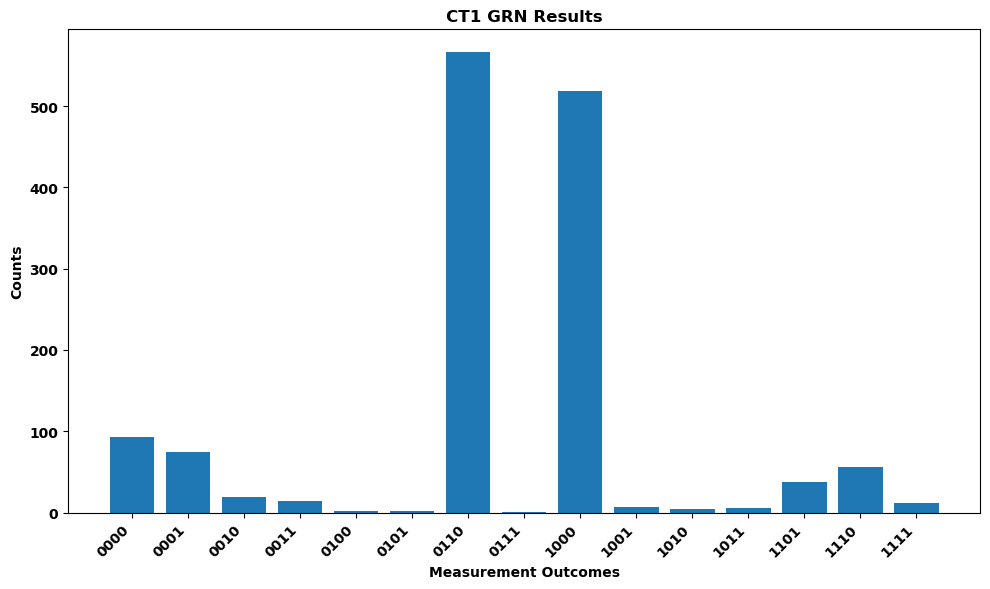

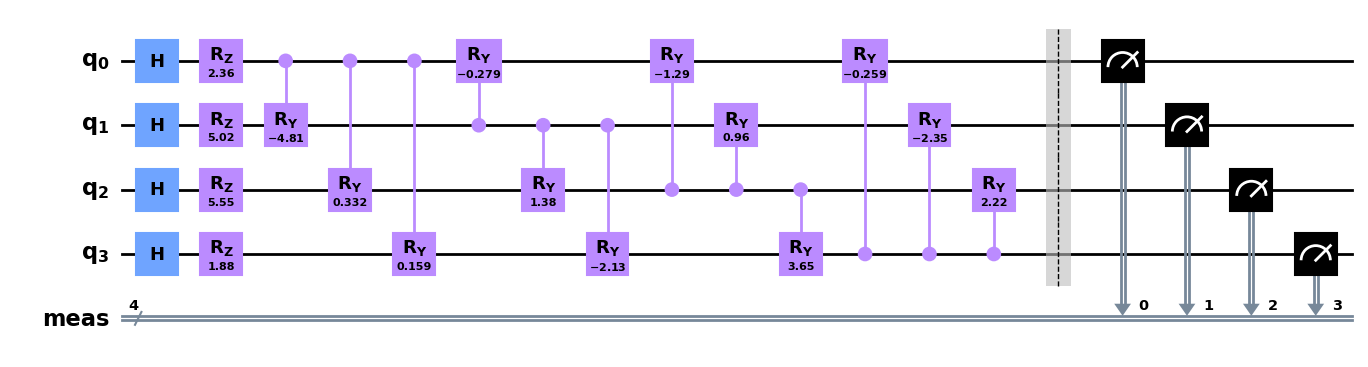

In [19]:
counts_ct1_co, bound_circuit_ct1_co = evaluate_and_plot_ansatz(ansatz_grn_ct1_co, all_params_ct1_co, shots=sum(joint_counts_ct1_co.values()), title="CT1 GRN Results")

bound_circuit_ct1_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT2 from histogram: SparsePauliOp(['ZZ', 'ZI', 'IZ'],
              coeffs=[-318.+0.j, -368.+0.j, -238.+0.j])
Static Parameters: {Parameter(ct2_act_0): 3.255487251303018, Parameter(ct2_act_1): 2.638558180356382}
Variable Parameters: [Parameter(ct2_grn_0_1), Parameter(ct2_grn_1_0)]
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -58.640396280123106
        x: [ 1.299e+00 -2.527e+00]
      nit: 8
      jac: [ 4.974e-06 -4.974e-06]
     nfev: 27
     njev: 9
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


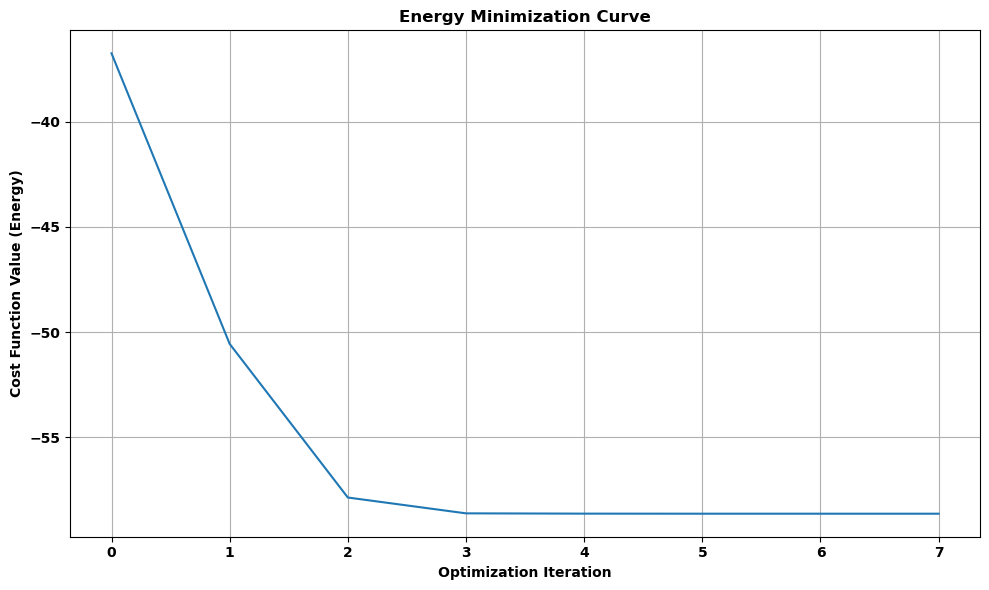

In [20]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features2 = Xct2bool.shape[1]  # Get the number of features dynamically

interaction_observable_ct2_co = create_interaction_observable_from_histogram(joint_counts_ct2_co, num_features2, min_ones = 1, standardize=False)
print("Interaction observable CT2 from histogram:", interaction_observable_ct2_co)

static_params2, variable_params2 = create_parameter_dictionaries(ansatz_grn_ct2_co, ct2_percentages)

print("Static Parameters:", static_params2)
print("Variable Parameters:", variable_params2)

estimator = StatevectorEstimator()
# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params2))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct2_co = static_params2.copy()  # Start with static parameters
all_params_ct2_co.update(dict(zip(variable_params2, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args, using a lambda for the callback
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct2_co, ansatz_grn_ct2_co, interaction_observable_ct2_co, estimator, variable_params2),
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct2_co, ansatz_grn_ct2_co, interaction_observable_ct2_co, estimator, variable_params2))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params2, optimized_variable_parameters):
    all_params_ct2_co[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'01': 491, '00': 276, '11': 246, '10': 11}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


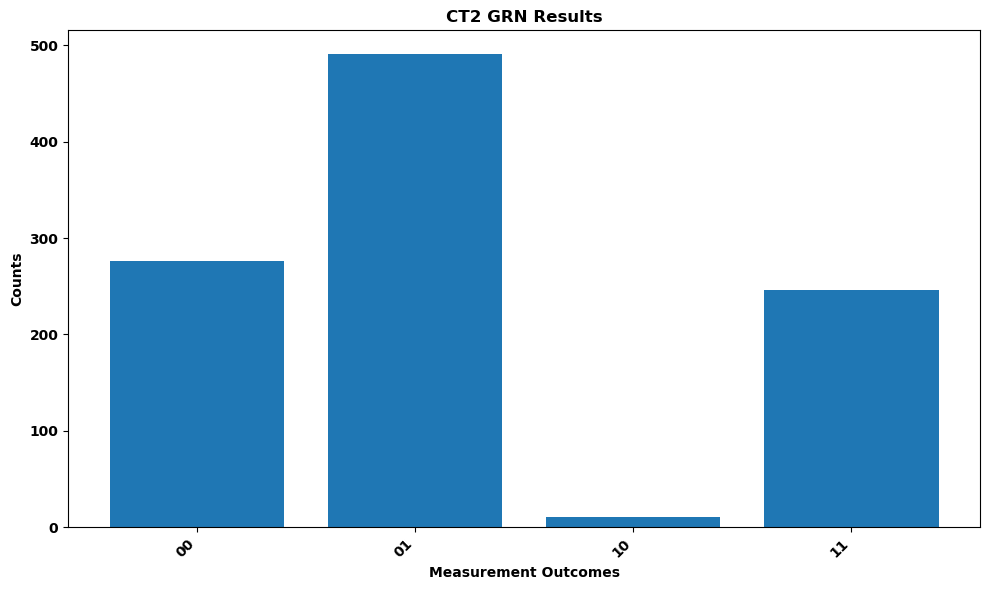

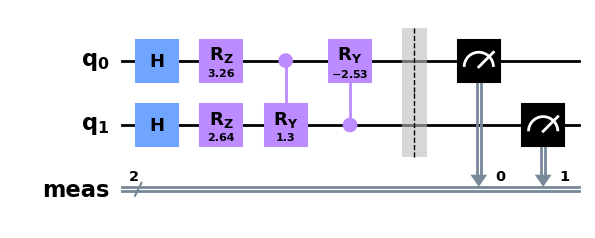

In [21]:
counts_ct2_co, bound_circuit_ct2_co = evaluate_and_plot_ansatz(ansatz_grn_ct2_co, all_params_ct2_co, title="CT2 GRN Results")

bound_circuit_ct2_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

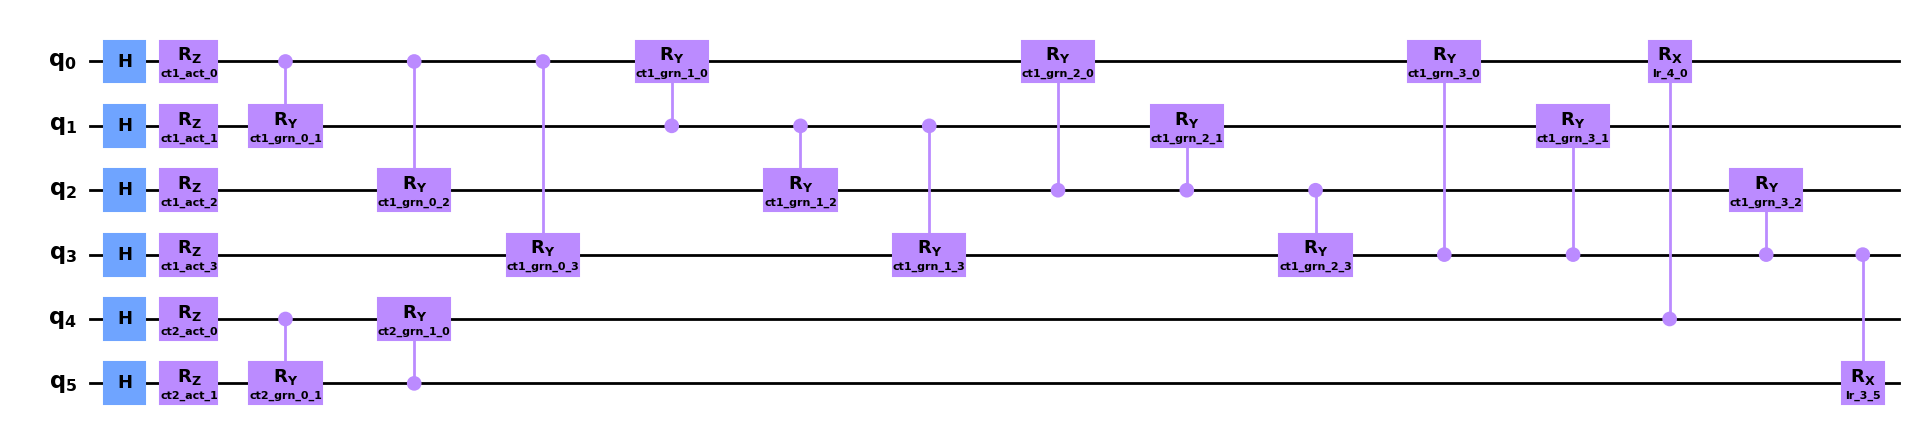

In [22]:
# interactions_lr = {
#     (4, 0): -1,
#     (3, 6): -1
# }
interactions_lr = {
    (ng_ct1, 0): -1,
    (ng_ct1-1, ng_ct1 + ng_ct2 -1): -1
}

cc_grn_circuit_mo = create_circuit_lr2(ansatz_grn_ct1_mo, ansatz_grn_ct2_mo, interactions = interactions_lr)
#cc_grn_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot
cc_grn_circuit_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

{Parameter(ct1_act_0): 2.3096819086036633, Parameter(ct1_act_1): 5.071200324068803, Parameter(ct1_act_2): 5.650614197573519, Parameter(ct1_act_3): 0.6219396623857967, Parameter(ct1_grn_0_1): -1.743275010707468, Parameter(ct1_grn_0_2): -0.7173749529632218, Parameter(ct1_grn_0_3): -1.120234186818397, Parameter(ct1_grn_1_0): -2.120244131028651, Parameter(ct1_grn_1_2): 1.9567998067956698, Parameter(ct1_grn_1_3): 0.8840792254472218, Parameter(ct1_grn_2_0): 0.9331038682495899, Parameter(ct1_grn_2_1): 1.2307852738698657, Parameter(ct1_grn_2_3): -1.7229014347593092, Parameter(ct1_grn_3_0): 0.5291832799006125, Parameter(ct1_grn_3_1): -1.4741698511294326, Parameter(ct1_grn_3_2): -1.1725926856912596, Parameter(ct2_act_0): 2.6998766133433083, Parameter(ct2_act_1): 1.8344737589828493, Parameter(ct2_grn_0_1): 1.3966306754875613, Parameter(ct2_grn_1_0): 1.1349451591168986, Parameter(lr_3_5): 0.0, Parameter(lr_4_0): 0.0}
Interaction observable LR custom:  SparsePauliOp(['ZIIIZI', 'IIIZIZ'],
          

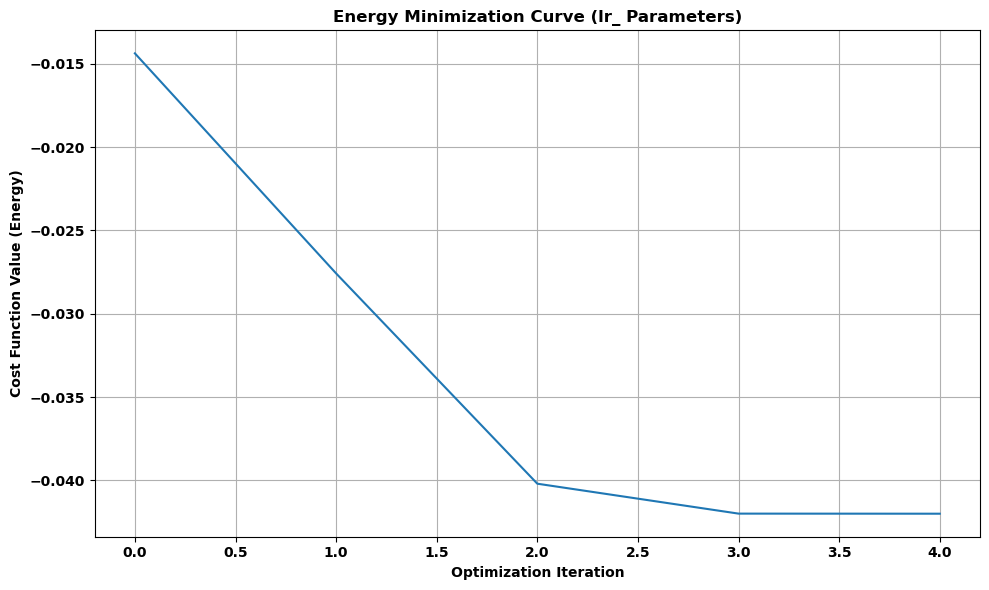

In [23]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_mo)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_mo[next(p for p in all_params_ct1_mo if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_mo[next(p for p in all_params_ct2_mo if p.name == param.name)]

x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_mo = static_params_lr.copy()
all_params_lr_mo.update(dict(zip(variable_params_lr.values(), x0_lr)))

print(all_params_lr_mo)

interactions = {
    (ng_ct1, 0): -1,
    (ng_ct1-1, ng_ct1 + ng_ct2 -1): -1
}

interaction_observable_lr_mo = create_interaction_observable_general(interactions, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_mo)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_mo.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'010001': 43, '000110': 83, '110001': 22, '110111': 59, '000001': 60, '110000': 27, '011111': 23, '000111': 41, '011001': 62, '010111': 111, '001000': 73, '100110': 80, '100111': 50, '100001': 74, '001001': 14, '010000': 39, '011110': 19, '110011': 3, '010011': 4, '000011': 2, '110110': 5, '001110': 21, '000000': 23, '010110': 12, '100000': 19, '111001': 9, '001111': 19, '000010': 8, '101111': 1, '101000': 3, '101001': 1, '011000': 3, '001011': 2, '100101': 1, '010101': 1, '111110': 2, '100010': 2, '110100': 1, '111111': 1, '001100': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


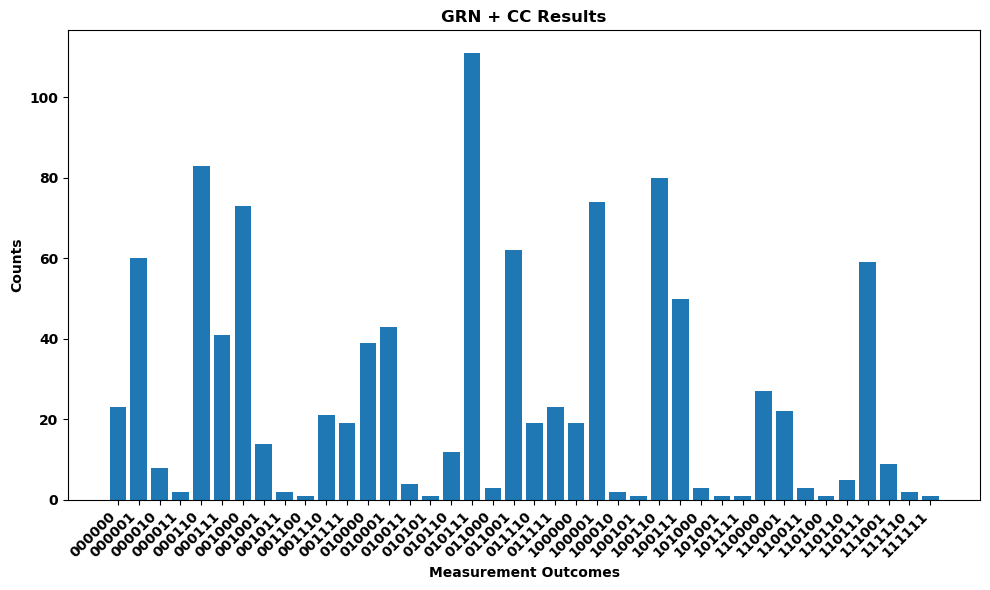

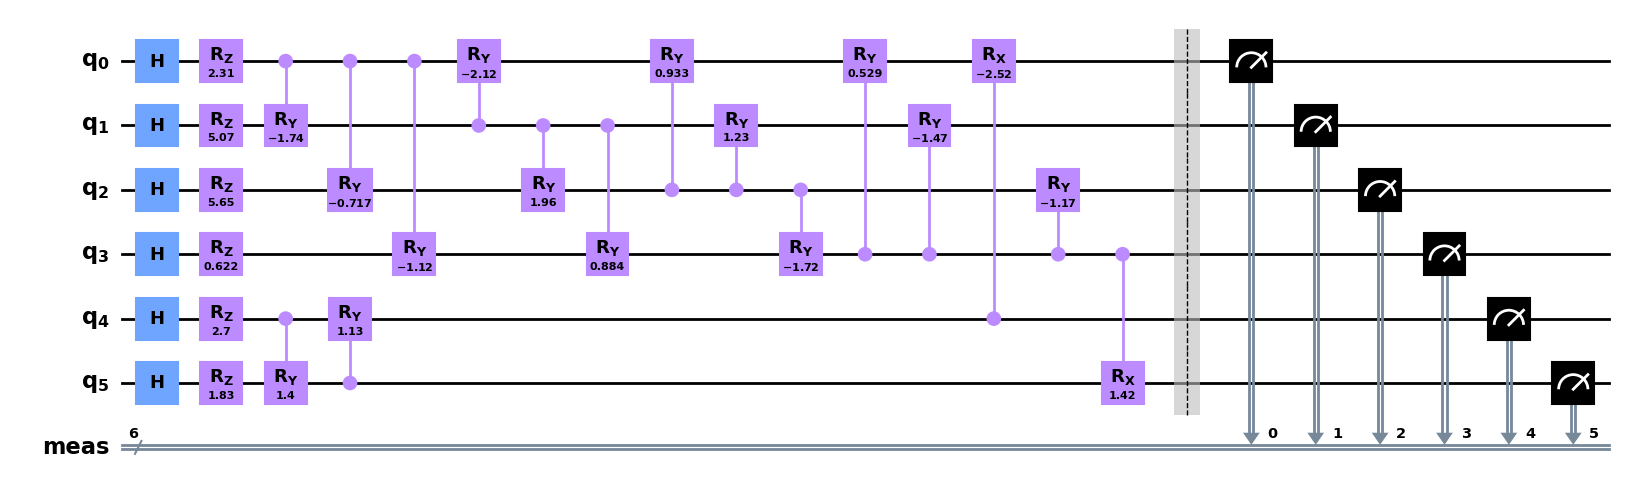

In [24]:
counts_cc_grn_mo, bound_circuit_cc_grn_mo = evaluate_and_plot_ansatz(cc_grn_circuit_mo, all_params_lr_mo, shots=1024, title="GRN + CC Results")

bound_circuit_cc_grn_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

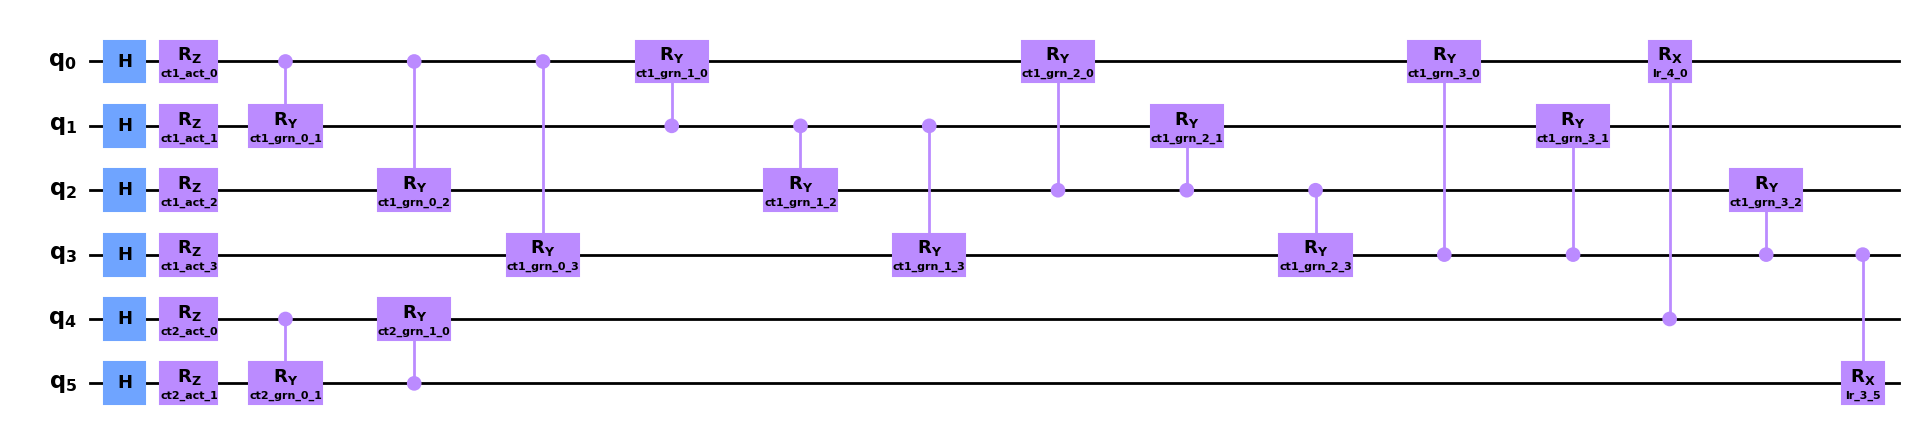

In [25]:
cc_grn_circuit_co = create_circuit_lr2(ansatz_grn_ct1_co, ansatz_grn_ct2_co, interactions = interactions_lr)
#cc_grn_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot
cc_grn_circuit_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

{Parameter(ct1_act_0): 2.3550836017009766, Parameter(ct1_act_1): 5.0212159809851, Parameter(ct1_act_2): 5.545555348910979, Parameter(ct1_act_3): 1.8796233273953076, Parameter(ct1_grn_0_1): -4.812370151628588, Parameter(ct1_grn_0_2): 0.33187149057265236, Parameter(ct1_grn_0_3): 0.15924221162583885, Parameter(ct1_grn_1_0): -0.2791961297732197, Parameter(ct1_grn_1_2): 1.376982759404915, Parameter(ct1_grn_1_3): -2.1329643165224796, Parameter(ct1_grn_2_0): -1.2920239872998027, Parameter(ct1_grn_2_1): 0.9600733186691122, Parameter(ct1_grn_2_3): 3.6472301713842032, Parameter(ct1_grn_3_0): -0.2591296997491139, Parameter(ct1_grn_3_1): -2.354966045641516, Parameter(ct1_grn_3_2): 2.215320119193831, Parameter(ct2_act_0): 3.255487251303018, Parameter(ct2_act_1): 2.638558180356382, Parameter(ct2_grn_0_1): 1.2991109196226005, Parameter(ct2_grn_1_0): -2.5269641812438506, Parameter(lr_3_5): 0.0, Parameter(lr_4_0): 0.0}
Interaction observable LR custom:  SparsePauliOp(['ZIIIZI', 'IIIZIZ'],
             

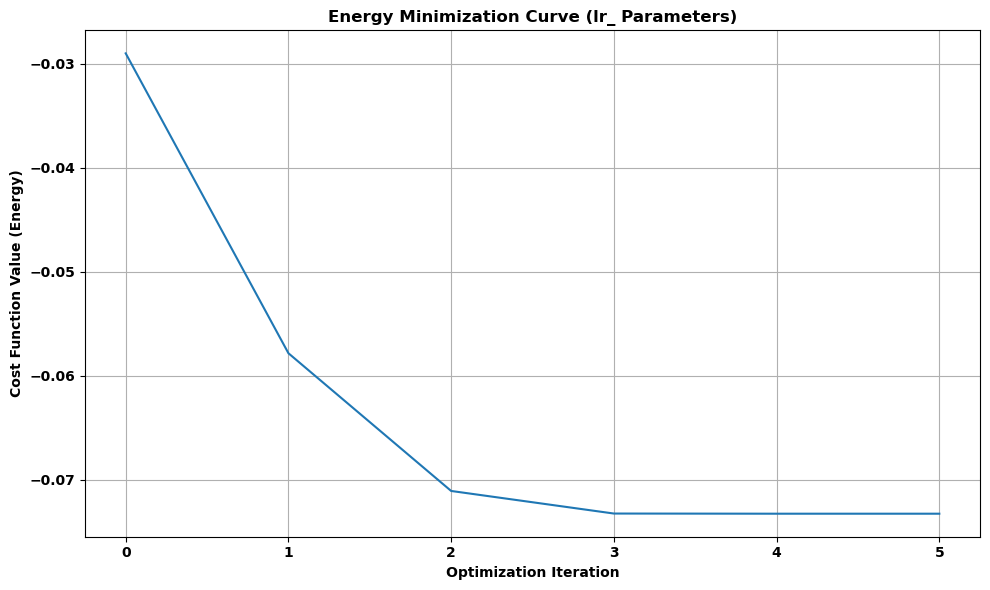

In [26]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_co)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_co[next(p for p in all_params_ct1_co if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_co[next(p for p in all_params_ct2_co if p.name == param.name)]

x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_co = static_params_lr.copy()
all_params_lr_co.update(dict(zip(variable_params_lr.values(), x0_lr)))

print(all_params_lr_co)


interactions = {
    (ng_ct1, 0): -1,
    (ng_ct1-1, ng_ct1 + ng_ct2 -1): -1
}

interaction_observable_lr_co = create_interaction_observable_general(interactions, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_co)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_co.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()


The counts are: {'000110': 129, '010111': 117, '110111': 82, '100110': 8, '001000': 84, '011000': 84, '000000': 24, '111001': 43, '010110': 58, '110110': 40, '011001': 121, '010001': 27, '111100': 5, '111000': 34, '110001': 16, '101000': 9, '101110': 2, '111111': 8, '001110': 6, '110000': 16, '011111': 17, '010000': 24, '010011': 5, '001010': 1, '000001': 9, '001101': 3, '000010': 3, '111101': 1, '011010': 3, '110010': 4, '011110': 9, '010100': 1, '101101': 2, '011100': 10, '011101': 3, '111110': 4, '010101': 1, '010010': 4, '101111': 1, '110011': 3, '001111': 1, '101010': 1, '000011': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


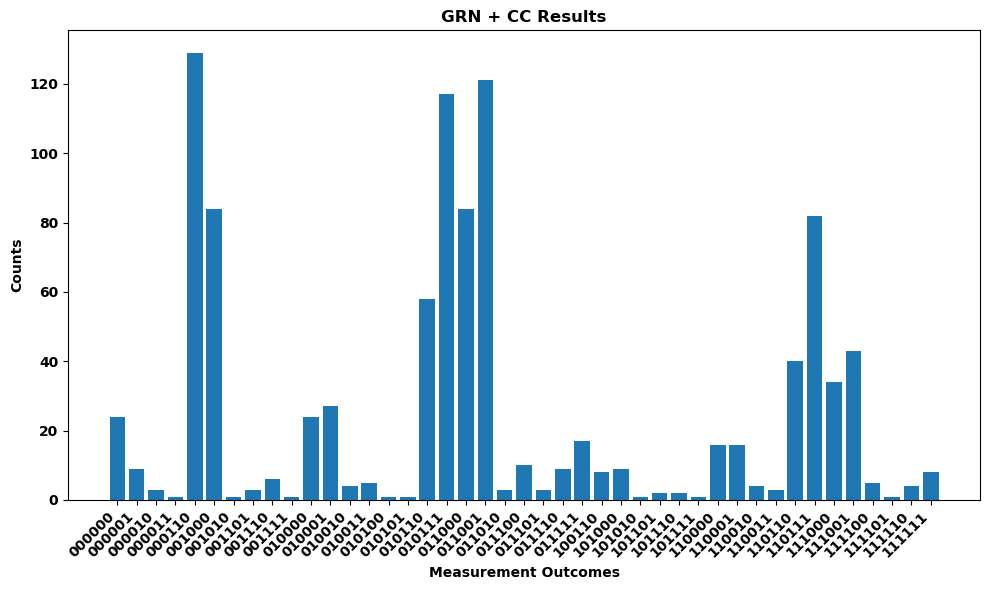

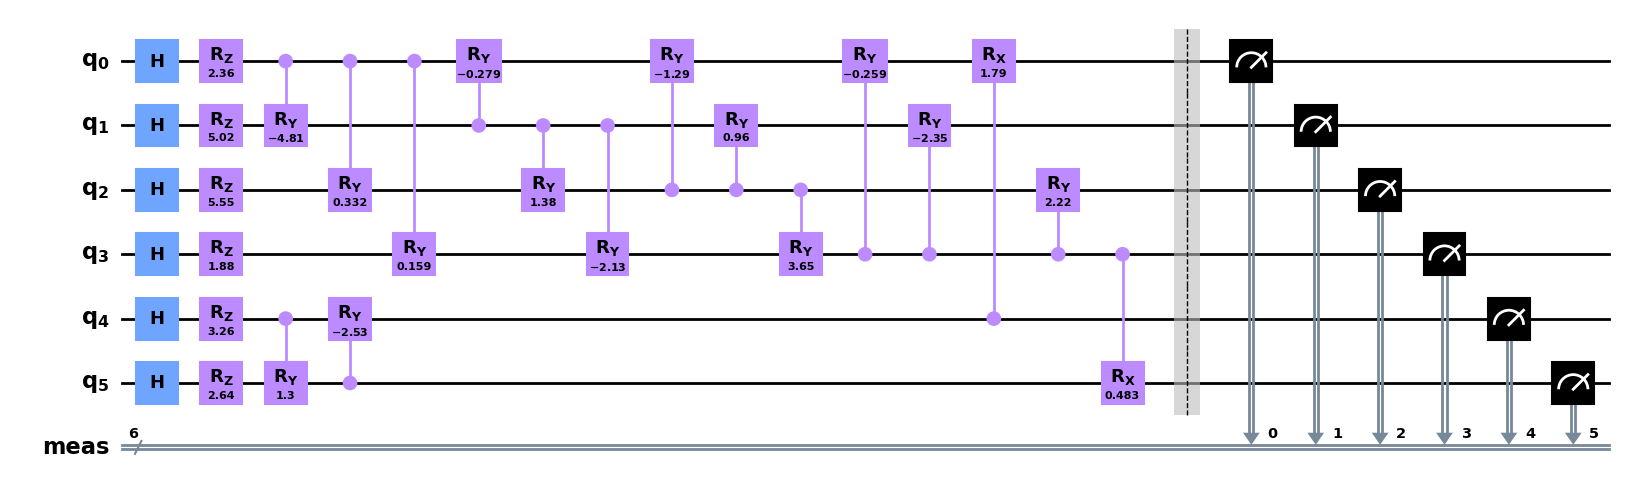

In [27]:
counts_cc_grn_co, bound_circuit_cc_grn_co = evaluate_and_plot_ansatz(cc_grn_circuit_co, all_params_lr_co, shots=1024, title="GRN + CC Results")

bound_circuit_cc_grn_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

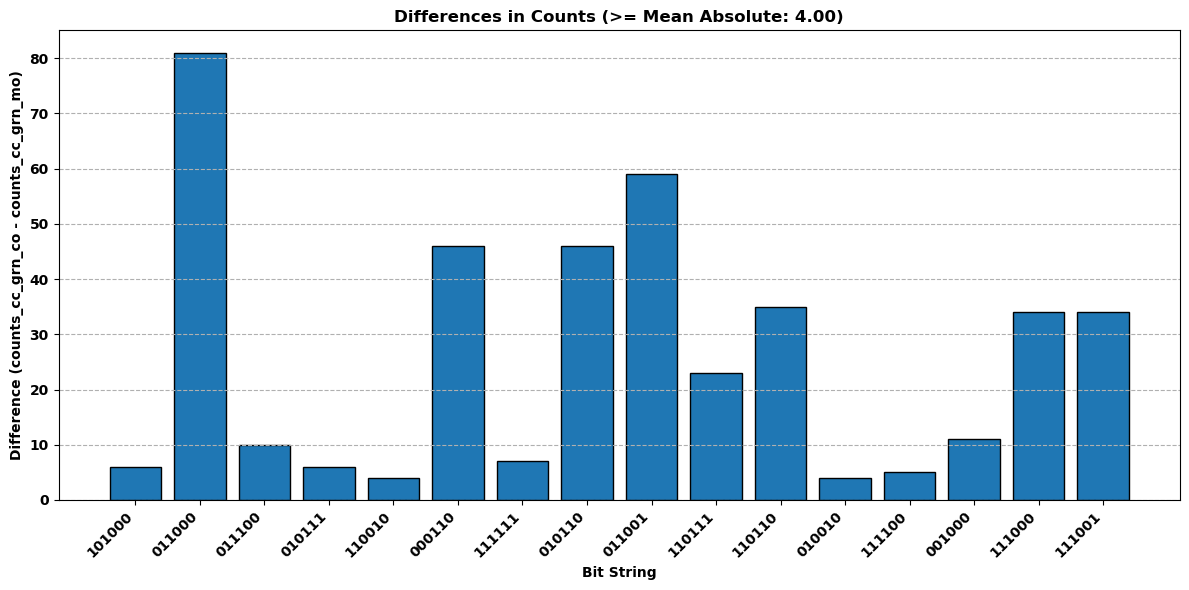

['PDGFRB', 'TGFB1', 'PDGFB', 'HIF1A', 'SMAD3', 'TGFBR2']


In [30]:
import matplotlib.pyplot as plt
import numpy as np

final_gl = gl_source + gl_recv
final_gl = final_gl[::-1]

differences = {}

# Calculate the differences
for key in set(counts_cc_grn_co.keys()) | set(counts_cc_grn_mo.keys()):
    count_co = counts_cc_grn_co.get(key, 0)
    count_mo = counts_cc_grn_mo.get(key, 0)
    differences[key] = count_co - count_mo

# Extract data for plotting
bitstrings = list(differences.keys())
difference_values = list(differences.values())

# Calculate the mean of the absolute differences
absolute_differences = [abs(diff) for diff in difference_values]
mean_absolute_difference = np.mean(absolute_differences)/4
#mean_absolute_difference = 0

# Filter out values below the mean of the absolute differences
filtered_bitstrings = []
filtered_differences = []

for i in range(len(difference_values)):
    #if abs(difference_values[i]) >= mean_absolute_difference:
    if difference_values[i] >= mean_absolute_difference:
        filtered_bitstrings.append(bitstrings[i])
        filtered_differences.append(difference_values[i])

# Create the bar plot with filtered data
plt.figure(figsize=(12, 6))
plt.bar(filtered_bitstrings, filtered_differences, edgecolor='black')
plt.xlabel('Bit String')
plt.ylabel('Difference (counts_cc_grn_co - counts_cc_grn_mo)')
plt.title(f'Differences in Counts (>= Mean Absolute: {mean_absolute_difference:.2f})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()
print(final_gl)

In [29]:
# gene order PDGFRB IL6 TGFB1 PDGFB HIF1A SMAD3 TGFBR2 
#gl_source = ['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'] # All values from the first column
#gl_recv =['TGFB1', 'IL6', 'PDGFRB']  # All values from the second column
